# Homework 1

This file contains the solutions to the computational problems in Homework 2 from MATH 5750 taught by Braxton Osting during the Fall 2026 semester.

This code is a mix between my own work, reference code released by Braxton Osting, and code generated by ChatGPT.

Import packages and first 10,000 images from dataset, scaling them to [0,1].

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
SEED = 0
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = X[:10000].astype(float) / 255.0
y = y[:10000].astype(int)

In [12]:
from pathlib import Path

import pandas as pd
from scipy.sparse.csgraph import shortest_path
from sklearn.datasets import (
    fetch_olivetti_faces,
    load_digits,
    load_iris,
    make_swiss_roll,
)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


In [7]:
print("Shape of data array:", X.shape)
counts = np.bincount(y, minlength=10)
for digit in range(10):
    print(f"Digit {digit}: {counts[digit]} images")

Shape of data array: (10000, 784)
Digit 0: 1001 images
Digit 1: 1127 images
Digit 2: 991 images
Digit 3: 1032 images
Digit 4: 980 images
Digit 5: 863 images
Digit 6: 1014 images
Digit 7: 1070 images
Digit 8: 944 images
Digit 9: 978 images


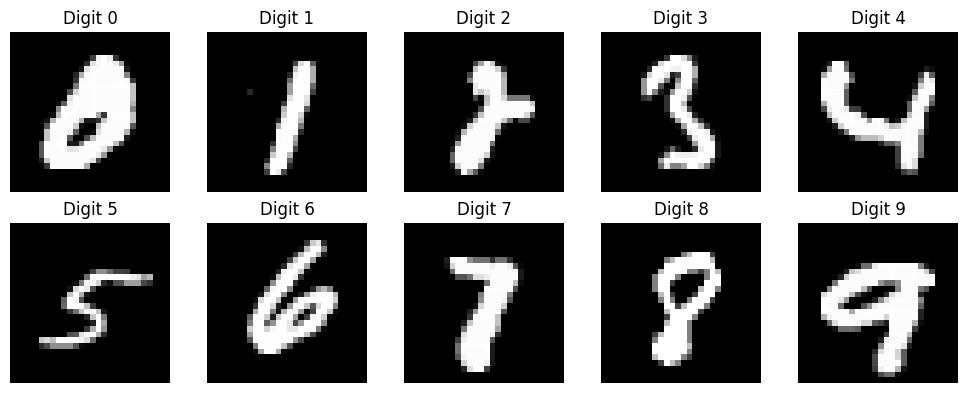

In [10]:
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in enumerate(axes.flat):
    possible_indices = np.where(y == digit)[0]
    index = rng.choice(possible_indices)

    ax.imshow(X[index].reshape(28, 28), cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Now we will fit PCA to the data.

In [16]:
pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

levels = [0.90, 0.95, 0.99]

for level in levels:
    k = np.searchsorted(cumulative, level) + 1
    compression_factor = 784 / k
    print(f"{int(level*100)}% variance: k = {k}, compression factor = {compression_factor:.2f}")

90% variance: k = 85, compression factor = 9.22
95% variance: k = 150, compression factor = 5.23
99% variance: k = 326, compression factor = 2.40


Make plots that are required in the homework assignment.

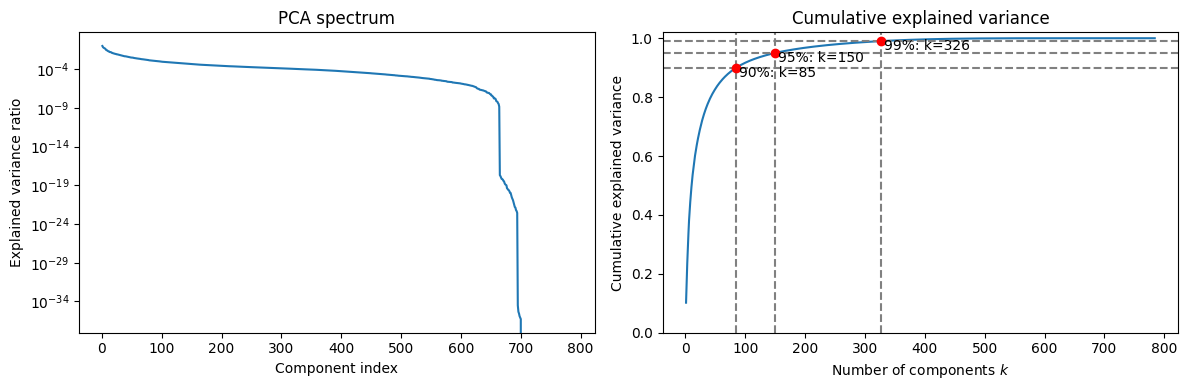

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: explained variance ratio, logarithmic vertical axis
axes[0].semilogy(
    np.arange(1, len(explained) + 1),
    explained
)
axes[0].set_xlabel("Component index")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("PCA spectrum")

# Right: cumulative variance
axes[1].plot(
    np.arange(1, len(cumulative) + 1),
    cumulative
)

for level in levels:
    k = np.searchsorted(cumulative, level) + 1

    axes[1].axhline(level, color="gray", linestyle="--")
    axes[1].axvline(k, color="gray", linestyle="--")
    axes[1].plot(k, cumulative[k - 1], "ro")
    axes[1].text(k + 5, level - 0.03, f"{int(level*100)}%: k={k}")

axes[1].set_xlabel("Number of components $k$")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance")
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()